In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


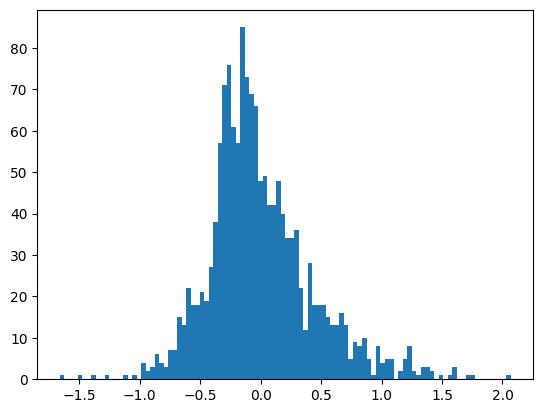

NameError: name 'exit' is not defined

In [ ]:
# from ExoRM.process_data import initialize_data
# from ExoRM.initialize_model import initialize_model

# initialize_data()
# initialize_model()

# Use these to initialize / update the model

In [3]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = False # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)

data

,name,radius,mass,density
0,1RXS J160929.1-210524 b,18.647000,2543.000000,0.392211
1,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562
2,55 Cnc e,1.910000,8.080000,1.159608
3,AU Mic b,4.203375,57.209400,0.770323
4,AU Mic c,3.240000,13.600000,0.399856
...,...,...,...,...
1496,XO-7 b,15.356304,225.658169,0.062315
1497,ZTF J1230-2655 b,13.787046,7024.007795,2.680225
1498,ZTF J1828+2308 b,11.130518,6356.568140,4.609742
1499,bet Pic b,16.800000,6356.000000,1.340467


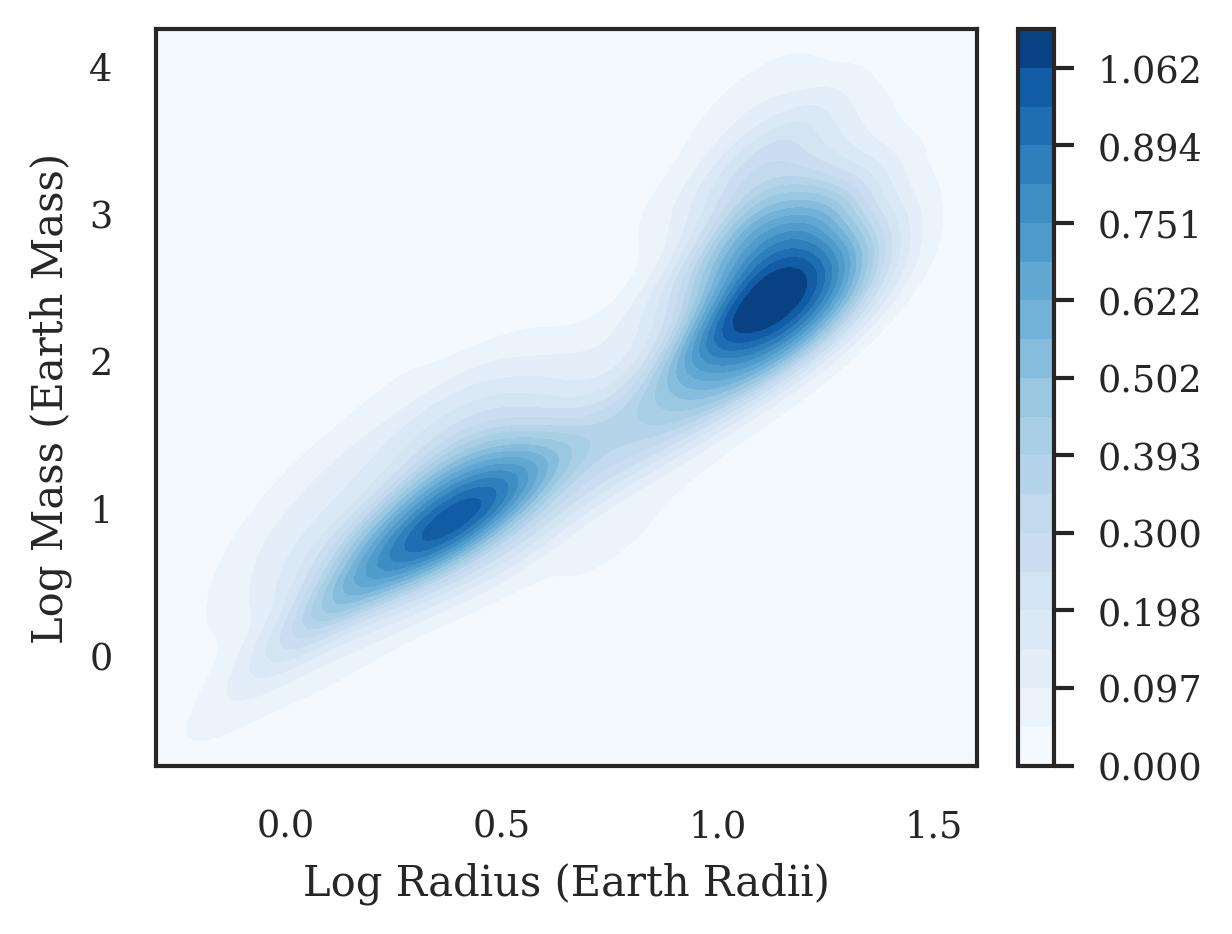

In [4]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
seaborn.kdeplot(pandas.DataFrame(numpy.log10(data[columns]), columns = columns), x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, thresh = 0, cbar = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

plot.xlim(-0.3, 1.6)
plot.ylim(-0.75, 4.25)

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

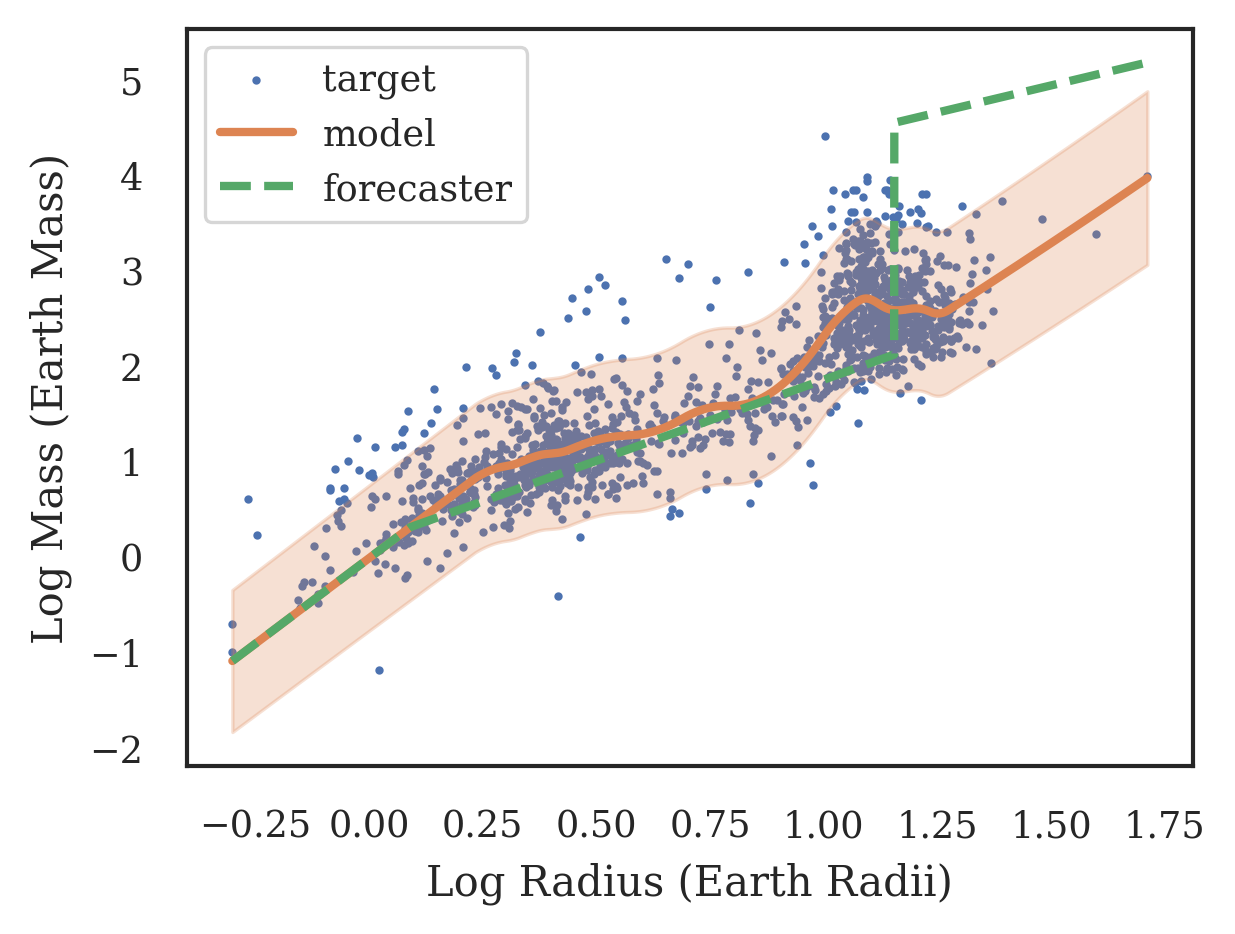

In [5]:
model = load_model()

xs = numpy.linspace(x.min(), x.max(), 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(x, y)

plot.plot(xs, ms, color = 'C1')
plot.plot(xs, ms2, '--', color = 'C2')

plot.fill_between(xs, ms - ms_e, ms + ms_e, color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [6]:
m = model(x)
m_e = model.error(x)
m_e2 = numpy.linspace(numpy.std(model.errors), numpy.std(model.errors), len(x))
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error2 = len(x[(y < (m - m_e2)) | (y > (m + m_e2))])
out_error / len(x), out_error2 / len(x), len(x)

(0.072618254497002, 0.4363757495003331, 1501)

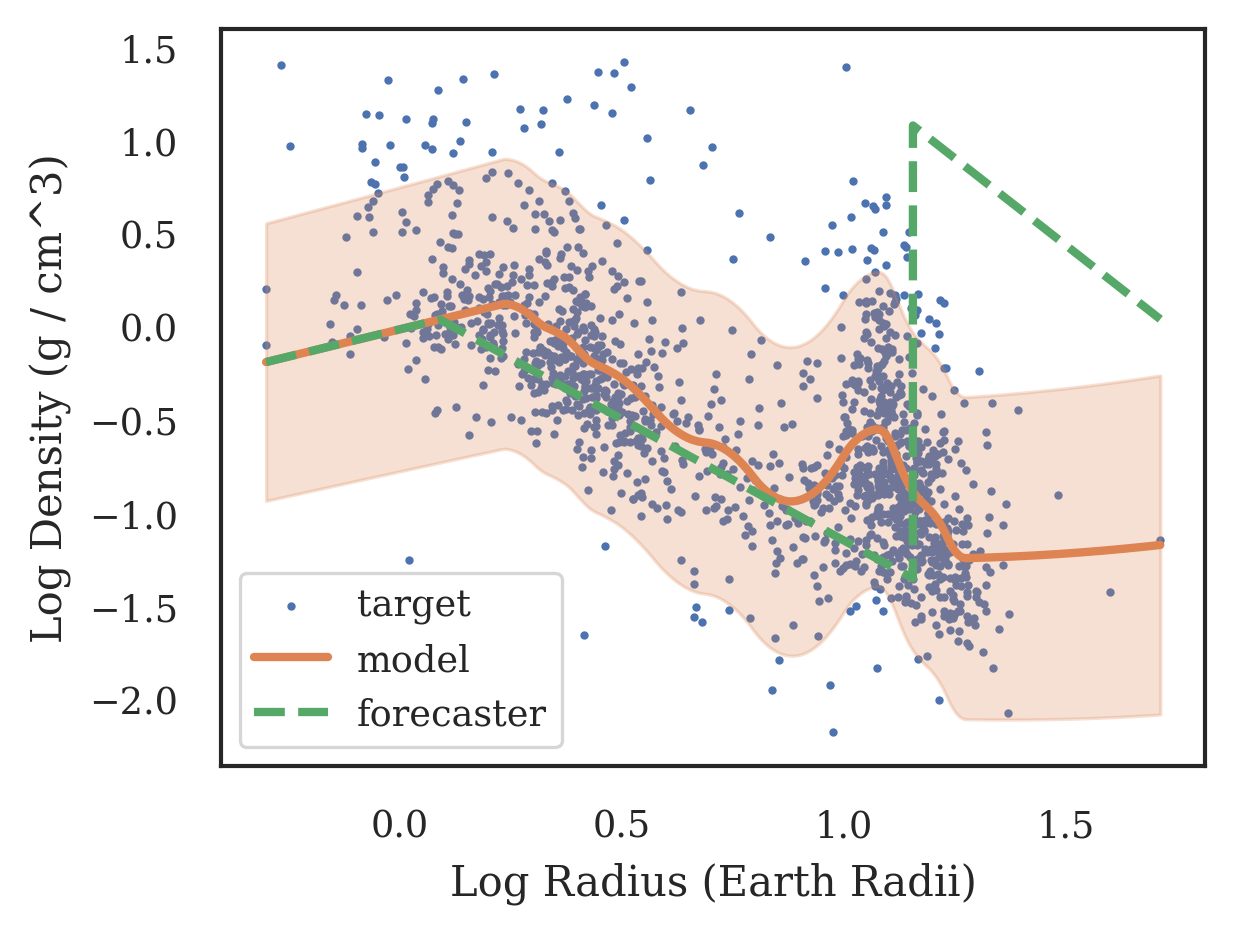

In [7]:
plot.scatter(x, numpy.log10((10 ** y) / ((10 ** x) ** 3)))
plot.plot(xs, numpy.log10((10 ** ms) / ((10 ** xs) ** 3)), color = 'C1')
plot.plot(xs, numpy.log10((10 ** ms2) / ((10 ** xs) ** 3)), '--', color = 'C2')

plot.fill_between(xs,
                  numpy.log10((10 ** (ms - ms_e)) / ((10 ** xs) ** 3)),
                  numpy.log10((10 ** (ms + ms_e)) / ((10 ** xs) ** 3)),
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Density (g / cm^3)')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

In [8]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.29805660247802734
Forecaster time (ms):  0.08211851119995117


In [9]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])

p_data

,name,radius,mass,density
0,1RXS J160929.1-210524 b,1.270609,3.405346,0.392211
1,2MASS J02192210-3925225 b,1.207929,3.645210,1.050562
2,55 Cnc e,0.281033,0.907411,1.159608
3,AU Mic b,0.623598,1.757467,0.770323
4,AU Mic c,0.510545,1.133539,0.399856
...,...,...,...,...
1496,XO-7 b,1.186287,2.353451,0.062315
1497,ZTF J1230-2655 b,1.139471,3.846585,2.680225
1498,ZTF J1828+2308 b,1.046515,3.803223,4.609742
1499,bet Pic b,1.225309,3.803184,1.340467


In [10]:
p_data['ExoRM'] = model(p_data['radius'])
p_data['Forecaster'] = ForecasterRM.forecaster(p_data['radius'])

p_data['ExoRM res'] = (p_data['mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

if save: p_data[['name'] + columns].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,ExoRM,Forecaster,ExoRM res,Forecaster res
0,PH1 b,0.79099,2.22790,0.716014,1.58250,1.50000,0.64535,0.727910
1,PH2 b,1.00380,4.40530,24.766050,2.33650,1.86130,2.06880,2.544000
2,K2-3 b,0.35984,0.81954,0.549588,1.04220,0.76797,-0.22270,0.051572
3,K2-3 c,0.22789,0.51851,0.683681,0.80440,0.54395,-0.28588,-0.025436
4,K2-3 d,0.18184,0.87506,2.135652,0.63937,0.46578,0.23569,0.409280
5,XO-1 b,1.12290,2.45640,0.122372,2.64420,2.06350,-0.18774,0.392910
6,XO-3 b,1.13480,3.57370,1.476223,2.61150,2.08380,0.96216,1.489900
7,XO-4 b,1.17350,2.75260,0.170671,2.58580,4.56690,0.16679,-1.814400
8,XO-5 b,1.10650,2.57770,0.181188,2.69050,2.03570,-0.11281,0.542020
9,XO-6 b,1.36550,3.14560,0.111953,2.86420,4.78490,0.28144,-1.639300


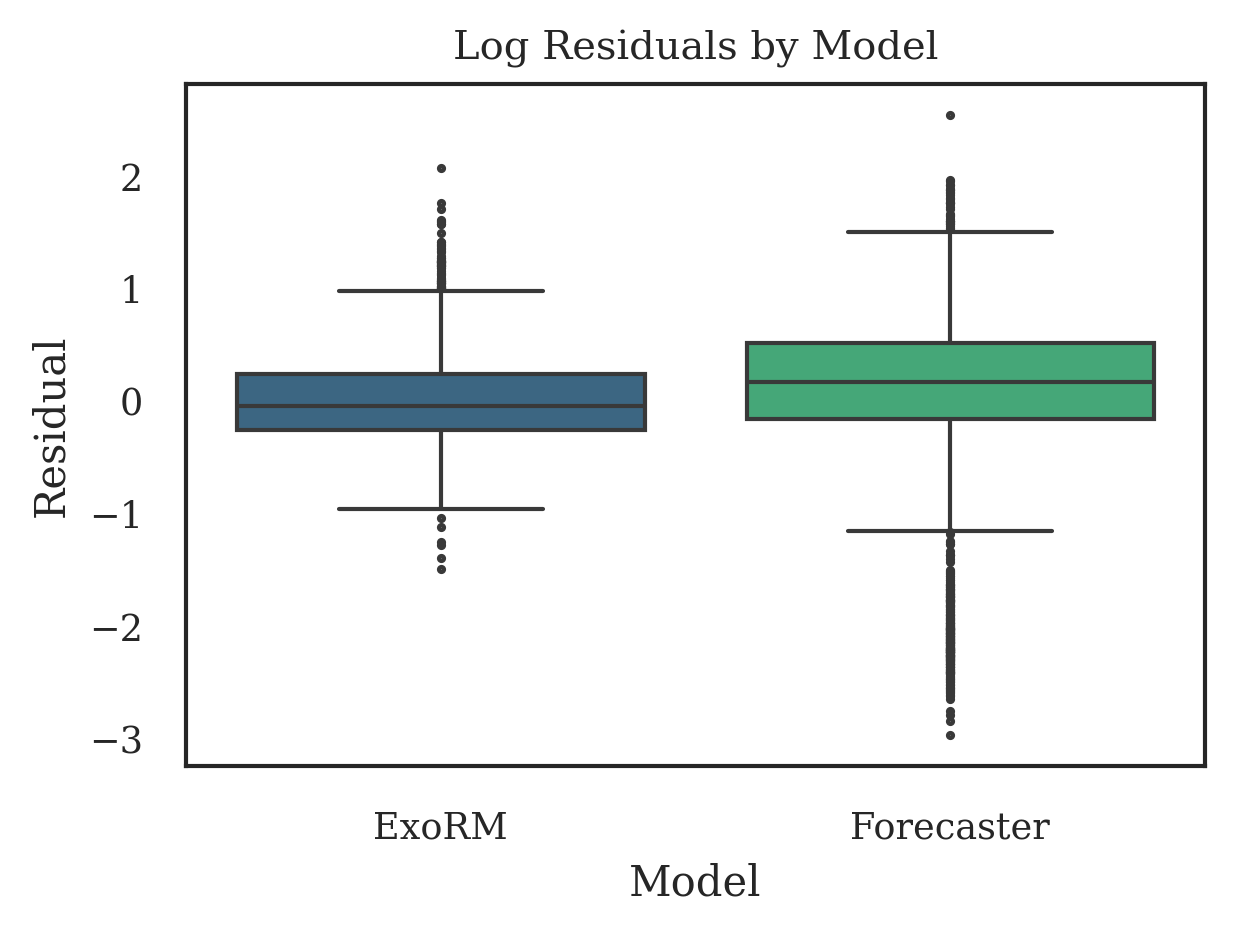

,Model,Residual
0,ExoRM,0.64535
1,ExoRM,2.06880
2,ExoRM,-0.22270
3,ExoRM,-0.28588
4,ExoRM,0.23569
...,...,...
2997,Forecaster,0.15377
2998,Forecaster,-1.27180
2999,Forecaster,-0.96084
3000,Forecaster,-0.97426


In [11]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['ExoRM res', 'Forecaster res'],
    var_name = 'Model',
    value_name = 'Residual'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'ExoRM res' else 'Forecaster')
seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Residual', hue = 'Model', palette = 'viridis', zorder = 1)

plot.title('Log Residuals by Model')

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

p_data_long

In [12]:
10 ** xs[numpy.argmin(numpy.abs((10 ** ms) - 317.9 * 13))]
# the deuterium burning limit radius

np.float64(40.16003009961013)